In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and EDA

In [140]:
movies_df = pd.read_csv("/kaggle/input/movielens-1m-dataset/movies.dat", sep="::", engine="python", names=['MovieID', 'Title', 'Genres'], encoding='latin-1')
ratings_df = pd.read_csv("/kaggle/input/movielens-1m-dataset/ratings.dat", sep="::", engine="python", names=['UserID', 'MovieID', 'Rating', 'Timestamp'], encoding='latin-1')
users_df = pd.read_csv("/kaggle/input/movielens-1m-dataset/users.dat", sep="::", engine="python", names=['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code'], encoding='latin-1')

In [141]:
movies_df

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
3878,3948,Meet the Parents (2000),Comedy
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama


In [142]:
ratings_df

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [143]:
users_df

,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455
...,...,...,...,...,...
6035,6036,F,25,15,32603
6036,6037,F,45,1,76006
6037,6038,F,56,1,14706
6038,6039,F,45,0,01060


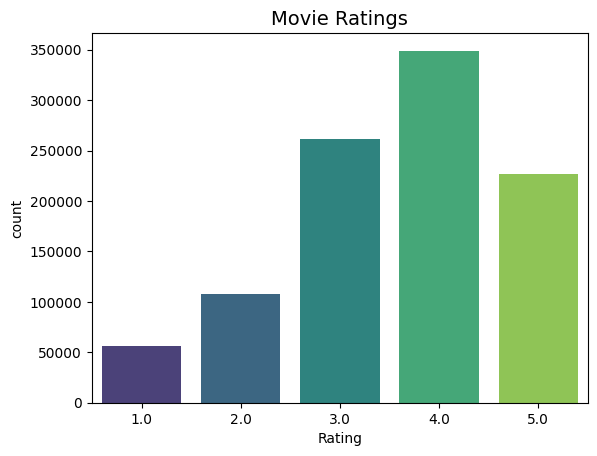

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


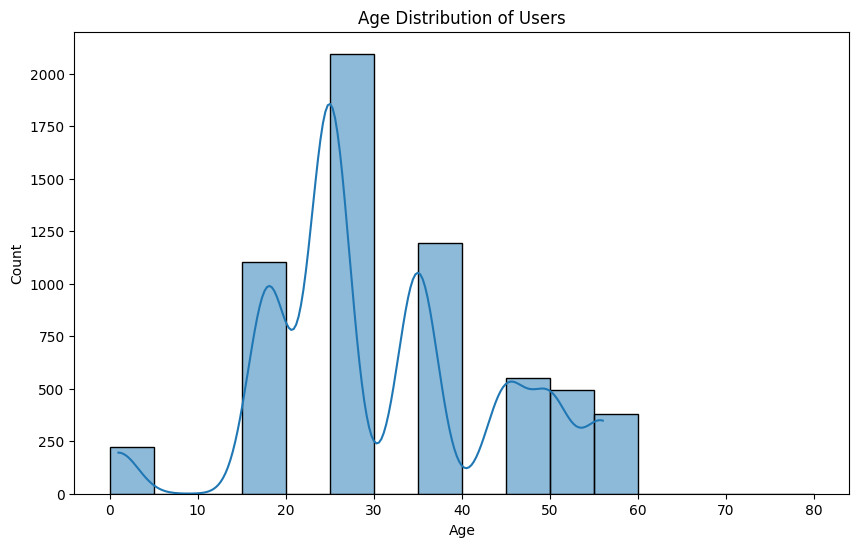

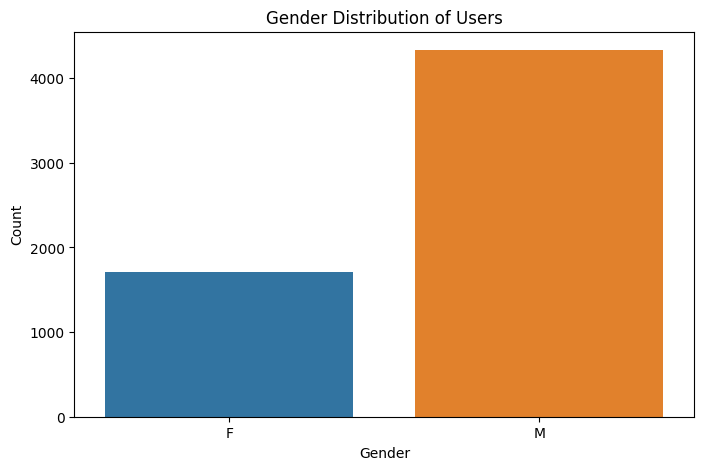

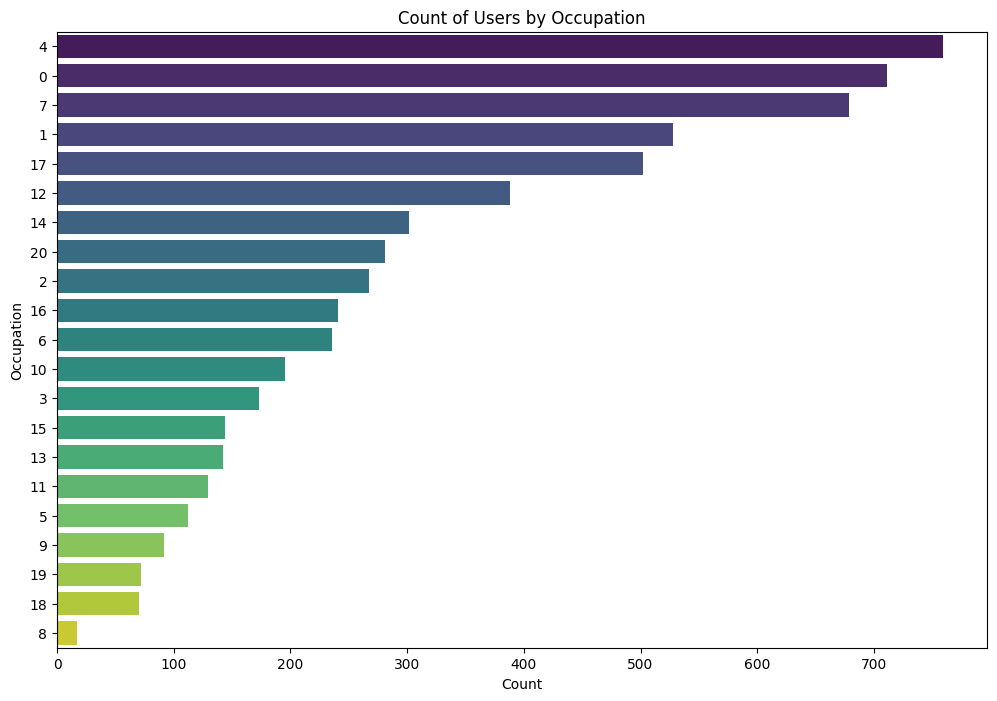

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Ratings
sns.countplot(x='Rating',data=df,palette="viridis")
plt.title('Movie Ratings', fontsize = 14)
plt.show()

# Age Distribution of Users
plt.figure(figsize=(10, 6))
sns.histplot(data=users_df, x='Age', bins=range(0, 81, 5), kde=True)
plt.title('Age Distribution of Users')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Gender Distribution of Users
plt.figure(figsize=(8, 5))
sns.countplot(data=users_df, x='Gender')
plt.title('Gender Distribution of Users')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# Plot count of users by occupation
plt.figure(figsize=(12, 8))
sns.countplot(y='Occupation', data=users_df, palette='viridis', order=users_df['Occupation'].value_counts().index)
plt.title('Count of Users by Occupation')
plt.xlabel('Count')
plt.ylabel('Occupation')
plt.show()

In [86]:
movie_ratings = ratings_df.merge(movies_df, on='MovieID')
movie_ratings['Title'].value_counts()[0:10]

Title
American Beauty (1999)                                   3428
Star Wars: Episode IV - A New Hope (1977)                2991
Star Wars: Episode V - The Empire Strikes Back (1980)    2990
Star Wars: Episode VI - Return of the Jedi (1983)        2883
Jurassic Park (1993)                                     2672
Saving Private Ryan (1998)                               2653
Terminator 2: Judgment Day (1991)                        2649
Matrix, The (1999)                                       2590
Back to the Future (1985)                                2583
Silence of the Lambs, The (1991)                         2578
Name: count, dtype: int64

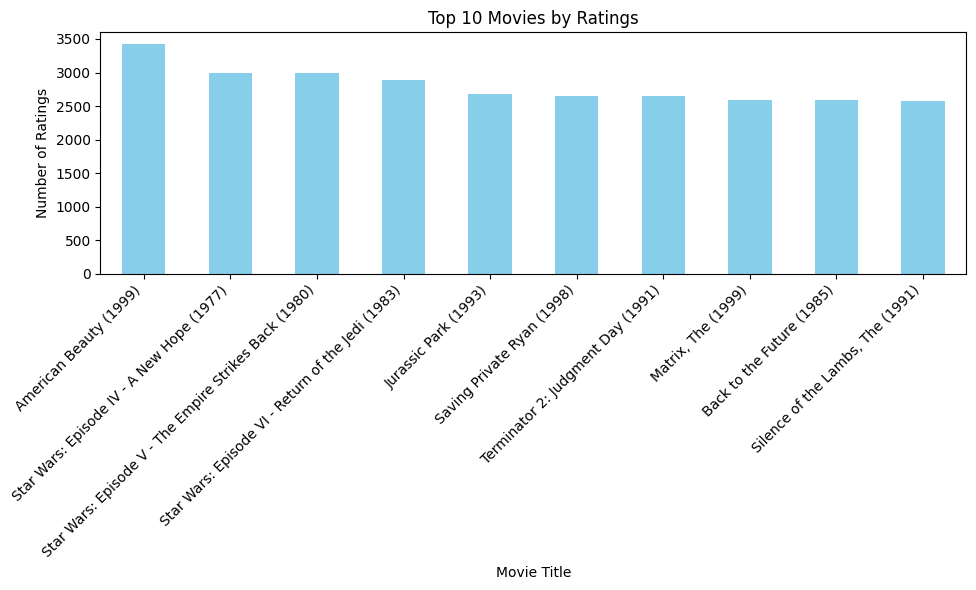

In [87]:
import matplotlib.pyplot as plt

#top 10 movies and their counts
top_movies = movie_ratings['Title'].value_counts().head(10)

# Plotting
plt.figure(figsize=(10, 6))
top_movies.plot(kind='bar', color='skyblue')
plt.title('Top 10 Movies by Ratings')
plt.xlabel('Movie Title')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [88]:
df = pd.merge(movies_df,ratings_df,how="outer",on="MovieID")

In [89]:
df.head()

,MovieID,Title,Genres,UserID,Rating,Timestamp
0,1,Toy Story (1995),Animation|Children's|Comedy,1.0,5.0,978824268.0
1,1,Toy Story (1995),Animation|Children's|Comedy,6.0,4.0,978237008.0
2,1,Toy Story (1995),Animation|Children's|Comedy,8.0,4.0,978233496.0
3,1,Toy Story (1995),Animation|Children's|Comedy,9.0,5.0,978225952.0
4,1,Toy Story (1995),Animation|Children's|Comedy,10.0,5.0,978226474.0


In [90]:
df = pd.merge(users_df,df,how="outer",on="UserID")

In [91]:
df

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Genres,Rating,Timestamp
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),Animation|Children's|Comedy,5.0,978824268.0
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),Animation|Children's|Musical|Romance,5.0,978824351.0
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),Drama,5.0,978301777.0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,4.0,978300760.0
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),Drama|War,5.0,978824195.0
...,...,...,...,...,...,...,...,...,...,...
1000381,NaN,NaN,NaN,NaN,NaN,3650,Anguish (Angustia) (1986),Horror,NaN,NaN
1000382,NaN,NaN,NaN,NaN,NaN,3750,Boricua's Bond (2000),Drama,NaN,NaN
1000383,NaN,NaN,NaN,NaN,NaN,3829,Mad About Mambo (2000),Comedy|Romance,NaN,NaN
1000384,NaN,NaN,NaN,NaN,NaN,3856,Autumn Heart (1999),Drama,NaN,NaN


In [92]:
df.isna().sum()

UserID        177
Gender        177
Age           177
Occupation    177
Zip-code      177
MovieID         0
Title           0
Genres          0
Rating        177
Timestamp     177
dtype: int64

In [93]:
df.dropna(inplace=True)

In [94]:
df.isna().sum()

UserID        0
Gender        0
Age           0
Occupation    0
Zip-code      0
MovieID       0
Title         0
Genres        0
Rating        0
Timestamp     0
dtype: int64

In [95]:
df

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Genres,Rating,Timestamp
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),Animation|Children's|Comedy,5.0,978824268.0
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),Animation|Children's|Musical|Romance,5.0,978824351.0
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),Drama,5.0,978301777.0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,4.0,978300760.0
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),Drama|War,5.0,978824195.0
...,...,...,...,...,...,...,...,...,...,...
1000204,6040.0,M,25.0,6.0,11106,3683,Blood Simple (1984),Drama|Film-Noir,4.0,960971696.0
1000205,6040.0,M,25.0,6.0,11106,3703,Mad Max 2 (a.k.a. The Road Warrior) (1981),Action|Sci-Fi,4.0,964828575.0
1000206,6040.0,M,25.0,6.0,11106,3735,Serpico (1973),Crime|Drama,4.0,960971654.0
1000207,6040.0,M,25.0,6.0,11106,3751,Chicken Run (2000),Animation|Children's|Comedy,4.0,964828782.0


In [96]:
df['Genres'] = df['Genres'].apply(lambda x: x.split('|'))

In [97]:
df

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Genres,Rating,Timestamp
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),"[Animation, Children's, Comedy]",5.0,978824268.0
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),"[Animation, Children's, Musical, Romance]",5.0,978824351.0
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),[Drama],5.0,978301777.0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),"[Action, Adventure, Fantasy, Sci-Fi]",4.0,978300760.0
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),"[Drama, War]",5.0,978824195.0
...,...,...,...,...,...,...,...,...,...,...
1000204,6040.0,M,25.0,6.0,11106,3683,Blood Simple (1984),"[Drama, Film-Noir]",4.0,960971696.0
1000205,6040.0,M,25.0,6.0,11106,3703,Mad Max 2 (a.k.a. The Road Warrior) (1981),"[Action, Sci-Fi]",4.0,964828575.0
1000206,6040.0,M,25.0,6.0,11106,3735,Serpico (1973),"[Crime, Drama]",4.0,960971654.0
1000207,6040.0,M,25.0,6.0,11106,3751,Chicken Run (2000),"[Animation, Children's, Comedy]",4.0,964828782.0


In [98]:
all_genres = set(genre for sublist in df['Genres'] for genre in sublist)

In [99]:
for genre in all_genres:
    df[f'{genre}'] = df['Genres'].apply(lambda x: 1 if genre in x else 0)
df = df.drop(columns=['Genres'])

In [100]:
df

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Rating,Timestamp,Crime,...,Animation,Mystery,Drama,Sci-Fi,Western,Adventure,Fantasy,Horror,Musical,Romance
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),5.0,978824268.0,0,...,1,0,0,0,0,0,0,0,0,0
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),5.0,978824351.0,0,...,1,0,0,0,0,0,0,0,1,1
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),5.0,978301777.0,0,...,0,0,1,0,0,0,0,0,0,0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),4.0,978300760.0,0,...,0,0,0,1,0,1,1,0,0,0
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),5.0,978824195.0,0,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000204,6040.0,M,25.0,6.0,11106,3683,Blood Simple (1984),4.0,960971696.0,0,...,0,0,1,0,0,0,0,0,0,0
1000205,6040.0,M,25.0,6.0,11106,3703,Mad Max 2 (a.k.a. The Road Warrior) (1981),4.0,964828575.0,0,...,0,0,0,1,0,0,0,0,0,0
1000206,6040.0,M,25.0,6.0,11106,3735,Serpico (1973),4.0,960971654.0,1,...,0,0,1,0,0,0,0,0,0,0
1000207,6040.0,M,25.0,6.0,11106,3751,Chicken Run (2000),4.0,964828782.0,0,...,1,0,0,0,0,0,0,0,0,0


In [101]:
ratings_cnt = len(df['Rating'])
movies_cnt = df['MovieID'].nunique()
users_cnt = df['UserID'].nunique()

In [102]:
print(f"Total ratings in the dataset: {ratings_cnt}")

Total ratings in the dataset: 1000209


In [103]:
print(f"Number of movies in the dataset: {movies_cnt}")


Number of movies in the dataset: 3706


In [104]:
print(f"Number of users in the dataset: {users_cnt}")

Number of users in the dataset: 6040


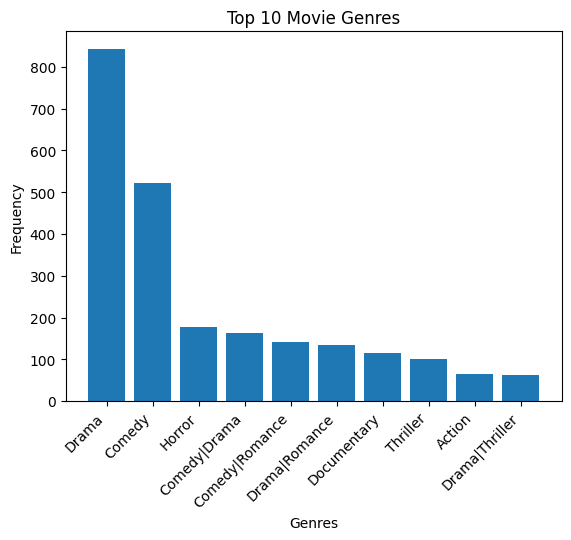

In [106]:
# Plot bar chart of movie genres
genre_counts = movies_df['Genres'].value_counts()[:10]
plt.bar(genre_counts.index, genre_counts.values)
plt.xlabel('Genres')
plt.ylabel('Frequency')
plt.title('Top 10 Movie Genres')
plt.xticks(rotation=45, ha='right')
plt.show()



* # Non uniform distribution

In [107]:
print(f"Mean rating: {round(df['Rating'].mean(),2)}.")

Mean rating: 3.58.


In [108]:
mean_ratings = df.groupby('UserID')['Rating'].mean()
print(f"Mean rating per user: {round(mean_ratings.mean(),2)}.")

Mean rating per user: 3.7.


In [109]:
movie_ratings = ratings_df.merge(movies_df, on='MovieID')
movie_ratings['Title'].value_counts()[0:10]

Title
American Beauty (1999)                                   3428
Star Wars: Episode IV - A New Hope (1977)                2991
Star Wars: Episode V - The Empire Strikes Back (1980)    2990
Star Wars: Episode VI - Return of the Jedi (1983)        2883
Jurassic Park (1993)                                     2672
Saving Private Ryan (1998)                               2653
Terminator 2: Judgment Day (1991)                        2649
Matrix, The (1999)                                       2590
Back to the Future (1985)                                2583
Silence of the Lambs, The (1991)                         2578
Name: count, dtype: int64

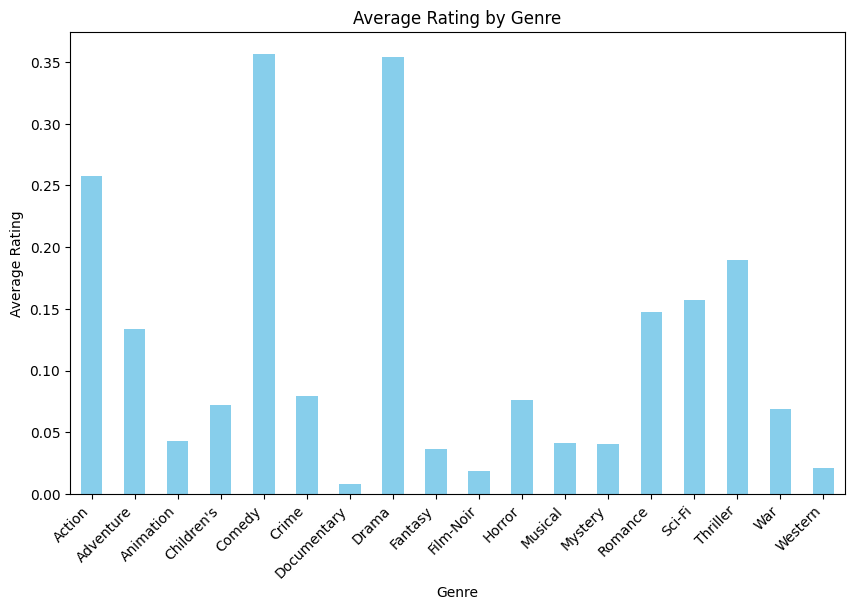

In [149]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Merge movies and ratings DataFrames
merged_df = pd.merge(movies_df, ratings_df, on='MovieID')

# Extract genres into separate columns
genres = merged_df['Genres'].str.get_dummies('|')

# Concatenate genres with ratings
genres_ratings = pd.concat([genres, merged_df['Rating']], axis=1)

# Calculate average rating for each genre
average_ratings = genres_ratings.drop(columns=['Rating']).mean()  # Exclude 'Rating' column

# Plot bar plot for average ratings
plt.figure(figsize=(10, 6))
average_ratings.plot(kind='bar', color='skyblue')
plt.title('Average Rating by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.show()

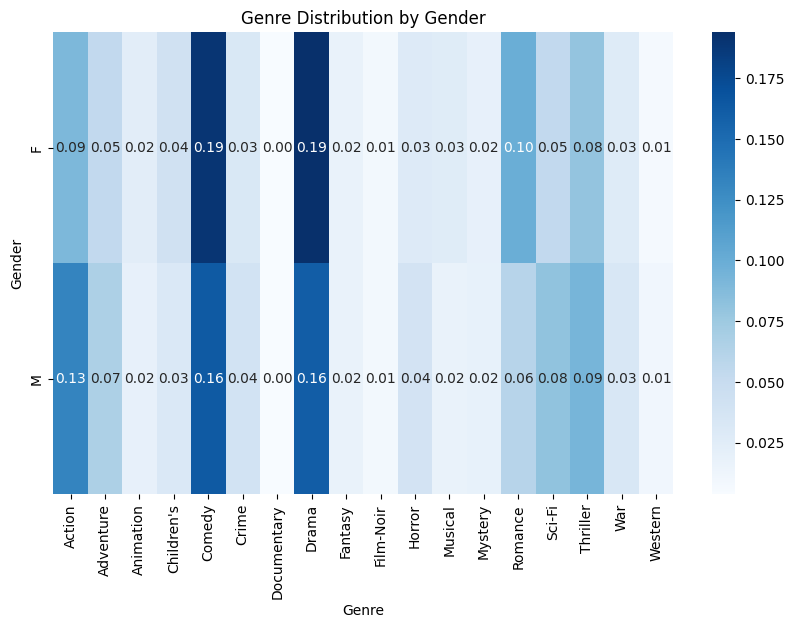

In [136]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Merge movies and ratings DataFrames
merged_df = pd.merge(movies_df, ratings_df, on='MovieID')
merged_df = pd.merge(merged_df, users_df, on='UserID')
genres = merged_df['Genres'].str.get_dummies('|')

# Count the occurrences of each genre for each gender
genre_gender_counts = df.groupby('Gender')[genres.columns].sum()

# Normalize counts to get percentages
genre_gender_perc = genre_gender_counts.div(genre_gender_counts.sum(axis=1), axis=0)

# Plot heatmap for genre distribution by gender
plt.figure(figsize=(10, 6))
sns.heatmap(genre_gender_perc, cmap='Blues', annot=True, fmt='.2f')
plt.title('Genre Distribution by Gender')
plt.xlabel('Genre')
plt.ylabel('Gender')
plt.show()


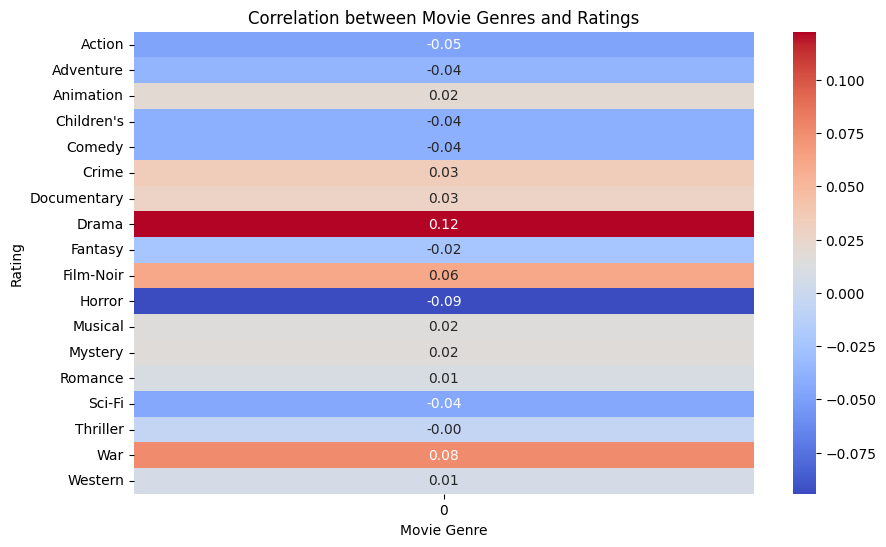

In [137]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Merge movies and ratings DataFrames
merged_df = pd.merge(movies_df, ratings_df, on='MovieID')

# Extract genres into separate columns
genres = merged_df['Genres'].str.get_dummies('|')

# Compute correlation matrix between genres and ratings
corr_matrix = genres.corrwith(merged_df['Rating'])

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix.to_frame(), cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Correlation between Movie Genres and Ratings')
plt.xlabel('Movie Genre')
plt.ylabel('Rating')
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


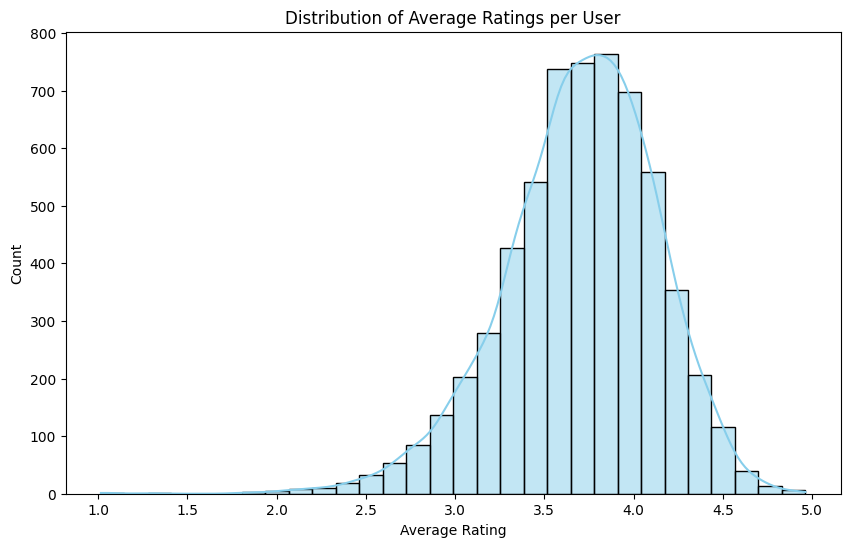

In [151]:
# Calculate the average rating per user
avg_rating_per_user = ratings_df.groupby('UserID')['Rating'].mean()

# Plot the distribution of average ratings per user
plt.figure(figsize=(10, 6))
sns.histplot(avg_rating_per_user, bins=30, kde=True, color='skyblue')
plt.title('Distribution of Average Ratings per User')
plt.xlabel('Average Rating')
plt.ylabel('Count')
plt.show()


# Recommendation

In [115]:
df.head()

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Rating,Timestamp,Animation,...,Children's,War,Romance,Thriller,Documentary,Fantasy,Crime,Sci-Fi,Film-Noir,Comedy
0,1.0,F,1.0,10.0,48067,1,Toy Story (1995),5.0,978824268.0,1,...,1,0,0,0,0,0,0,0,0,1
1,1.0,F,1.0,10.0,48067,48,Pocahontas (1995),5.0,978824351.0,1,...,1,0,1,0,0,0,0,0,0,0
2,1.0,F,1.0,10.0,48067,150,Apollo 13 (1995),5.0,978301777.0,0,...,0,0,0,0,0,0,0,0,0,0
3,1.0,F,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),4.0,978300760.0,0,...,0,0,0,0,0,1,0,1,0,0
4,1.0,F,1.0,10.0,48067,527,Schindler's List (1993),5.0,978824195.0,0,...,0,1,0,0,0,0,0,0,0,0


In [116]:
df.columns

Index(['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code', 'MovieID', 'Title',
       'Rating', 'Timestamp', 'Animation', 'Horror', 'Action', 'Mystery',
       'Adventure', 'Musical', 'Western', 'Drama', 'Children's', 'War',
       'Romance', 'Thriller', 'Documentary', 'Fantasy', 'Crime', 'Sci-Fi',
       'Film-Noir', 'Comedy'],
      dtype='object')

In [119]:
df['Gender'] = df['Gender'].replace({'M': 1, 'F': 0})

In [120]:
df.head()

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Title,Rating,Timestamp,Animation,...,Children's,War,Romance,Thriller,Documentary,Fantasy,Crime,Sci-Fi,Film-Noir,Comedy
0,1.0,0,1.0,10.0,48067,1,Toy Story (1995),5.0,978824268.0,1,...,1,0,0,0,0,0,0,0,0,1
1,1.0,0,1.0,10.0,48067,48,Pocahontas (1995),5.0,978824351.0,1,...,1,0,1,0,0,0,0,0,0,0
2,1.0,0,1.0,10.0,48067,150,Apollo 13 (1995),5.0,978301777.0,0,...,0,0,0,0,0,0,0,0,0,0
3,1.0,0,1.0,10.0,48067,260,Star Wars: Episode IV - A New Hope (1977),4.0,978300760.0,0,...,0,0,0,0,0,1,0,1,0,0
4,1.0,0,1.0,10.0,48067,527,Schindler's List (1993),5.0,978824195.0,0,...,0,1,0,0,0,0,0,0,0,0


In [121]:
k_means_df = df.drop(columns=['Timestamp', 'Zip-code'])

In [122]:
k_means_df

,UserID,Gender,Age,Occupation,MovieID,Title,Rating,Animation,Horror,Action,...,Children's,War,Romance,Thriller,Documentary,Fantasy,Crime,Sci-Fi,Film-Noir,Comedy
0,1.0,0,1.0,10.0,1,Toy Story (1995),5.0,1,0,0,...,1,0,0,0,0,0,0,0,0,1
1,1.0,0,1.0,10.0,48,Pocahontas (1995),5.0,1,0,0,...,1,0,1,0,0,0,0,0,0,0
2,1.0,0,1.0,10.0,150,Apollo 13 (1995),5.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1.0,0,1.0,10.0,260,Star Wars: Episode IV - A New Hope (1977),4.0,0,0,1,...,0,0,0,0,0,1,0,1,0,0
4,1.0,0,1.0,10.0,527,Schindler's List (1993),5.0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000204,6040.0,1,25.0,6.0,3683,Blood Simple (1984),4.0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1000205,6040.0,1,25.0,6.0,3703,Mad Max 2 (a.k.a. The Road Warrior) (1981),4.0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1000206,6040.0,1,25.0,6.0,3735,Serpico (1973),4.0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1000207,6040.0,1,25.0,6.0,3751,Chicken Run (2000),4.0,1,0,0,...,1,0,0,0,0,0,0,0,0,1
